In [10]:
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display

In [11]:
groq_api_key = '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'
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")

In [12]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    sentiment: str

# 1. Preprocessing Node
def preprocess(state: State) -> State:
    cleaned = state["messages"][-1].content.strip()
    state["messages"][-1].content = cleaned
    return state

# 2. Sentiment Analysis Node
def analyze_sentiment(state: State) -> State:
    msg = state["messages"][-1].content
    state["sentiment"] = "positive" if "good" in msg else "neutral"
    return state

# 3. Chatbot Node
def chatbot(state: State) -> State:
    return {"messages": llm.invoke(state['messages'])}

# 4. Logging Node
def logger(state: State) -> State:
    print(f"LOG: {state['messages'][-1].content}, Sentiment: {state.get('sentiment')}")
    return state

In [13]:
# Build the graph
builder = StateGraph(State)
builder.add_node("preprocess", preprocess)
builder.add_node("analyze_sentiment", analyze_sentiment)  # renamed
builder.add_node("chatbot", chatbot)
builder.add_node("logger", logger)

In [14]:
# Define flow
builder.add_edge(START, "preprocess")
builder.add_edge("preprocess", "analyze_sentiment")  # renamed
builder.add_edge("analyze_sentiment", "chatbot")     # renamed
builder.add_edge("chatbot", "logger")
builder.add_edge("logger", END)

In [15]:
graph = builder.compile()

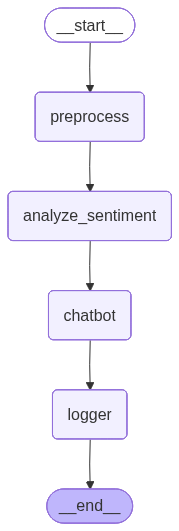

In [16]:
# Draw the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
# Invoke the graph
input_message = "This is a good test message."
final_state = graph.invoke({"messages": ("user", input_message)})

# Print the final state
print("Final State:", final_state)
print("Chatbot's response:", final_state['messages'][-1].content)
print("Detected Sentiment:", final_state['sentiment'])

input_message_2 = "This is a neutral message."
final_state_2 = graph.invoke({"messages": ("user", input_message_2)})
print("Final State 2:", final_state_2)
print("Chatbot's response 2:", final_state_2['messages'][-1].content)
print("Detected Sentiment 2:", final_state_2['sentiment'])

LOG: It looks like your test message has been successfully sent. If you have any questions or need help with anything, feel free to ask., Sentiment: positive
Final State: {'messages': [HumanMessage(content='This is a good test message.', additional_kwargs={}, response_metadata={}, id='b9d87634-1652-40e0-9f07-d4a71677c5bb'), AIMessage(content='It looks like your test message has been successfully sent. If you have any questions or need help with anything, feel free to ask.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.08120145, 'completion_tokens_details': None, 'prompt_time': 0.001978713, 'prompt_tokens_details': None, 'queue_time': 0.162131616, 'total_time': 0.083180163}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f416a-289d-7df1-a0a5-225